In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

print('Libraries ready!')

Libraries ready!


In [2]:
df = pd.read_csv('Data/cleaned_retail.csv', parse_dates=['InvoiceDate'])
print('Shape:', df.shape)
df.head()

Shape: (779425, 12)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalAmount,Month,DayOfWeek,Hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12,Tuesday,7


In [3]:
# Use 1 day after the last transaction as our reference date
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print('Reference date:', ref_date.date())

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate',  lambda x: (ref_date - x.max()).days),
    Frequency = ('Invoice',      'nunique'),
    Monetary  = ('TotalAmount',  'sum')
).reset_index()

print('RFM shape:', rfm.shape)
rfm.head()

Reference date: 2011-12-10
RFM shape: (5878, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [4]:
# Quick look at distributions
rfm[['Recency','Frequency','Monetary']].describe().round(2)

,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90
std,209.34,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


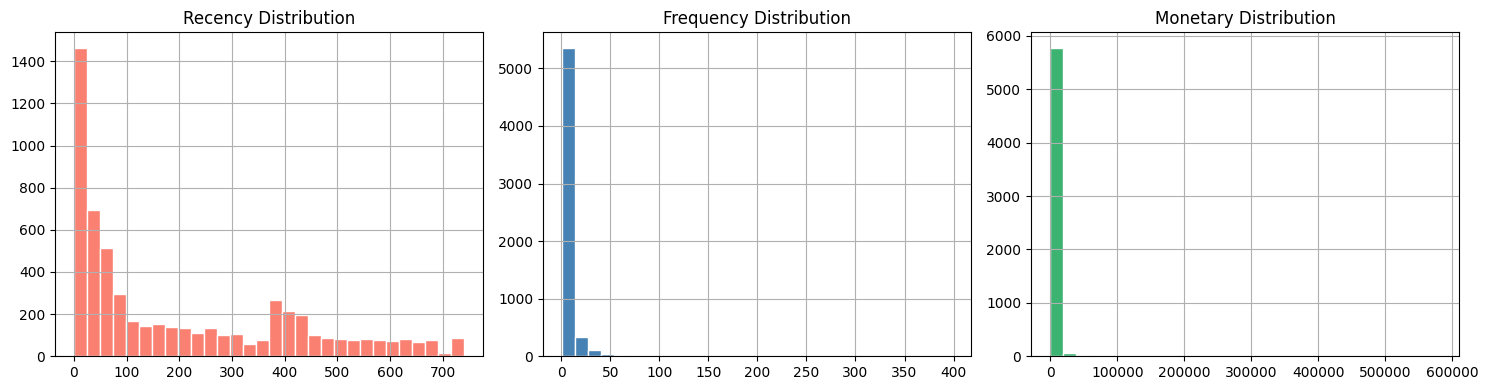

In [5]:
# Plot RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rfm['Recency'].hist(ax=axes[0],   bins=30, color='salmon',      edgecolor='white')
rfm['Frequency'].hist(ax=axes[1], bins=30, color='steelblue',   edgecolor='white')
rfm['Monetary'].hist(ax=axes[2],  bins=30, color='mediumseagreen', edgecolor='white')

axes[0].set_title('Recency Distribution')
axes[1].set_title('Frequency Distribution')
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

Active  : 2889
Churned : 2989


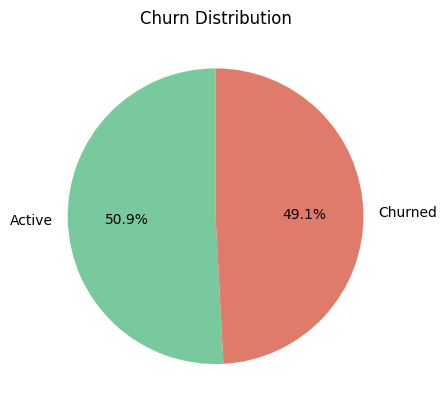

In [6]:
rfm['is_churned'] = (rfm['Recency'] > 90).astype(int)

print('Active  :', (rfm['is_churned'] == 0).sum())
print('Churned :', (rfm['is_churned'] == 1).sum())

# Pie chart
rfm['is_churned'].value_counts().plot(
    kind='pie',
    labels=['Active', 'Churned'],
    autopct='%1.1f%%',
    colors=['#79C99E', '#E07B6B'],
    startangle=90
)
plt.title('Churn Distribution')
plt.ylabel('')
plt.show()

In [7]:
# Log transform to reduce skew, then scale
rfm_model = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_model['Frequency'] = np.log1p(rfm_model['Frequency'])
rfm_model['Monetary']  = np.log1p(rfm_model['Monetary'])

scaler     = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_model)

print('Scaling done!')

Scaling done!


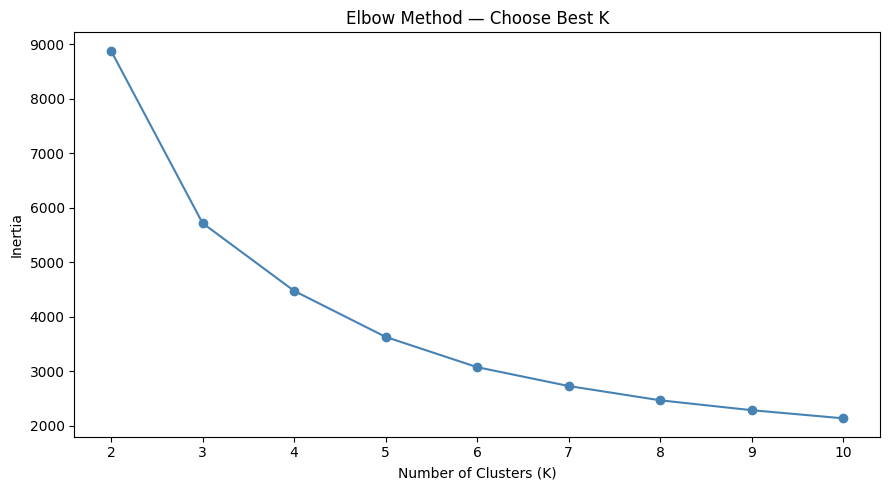

Pick K at the point where the curve bends (the elbow).


In [8]:
inertias = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), inertias, marker='o', color='steelblue')
plt.title('Elbow Method — Choose Best K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

print('Pick K at the point where the curve bends (the elbow).')

In [9]:
# Change K=4 if your elbow plot suggests a different number
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print('Cluster counts:')
print(rfm['Cluster'].value_counts().sort_index())

Cluster counts:
Cluster
0    1494
1    1646
2     876
3    1862
Name: count, dtype: int64


In [10]:
# Look at average RFM per cluster to understand them
cluster_means = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
print(cluster_means)

# Assign labels based on the cluster means
# Champions = highest monetary, lowest recency
# At Risk   = highest recency (haven't bought in a while)
# New       = lowest frequency
# Loyal     = the rest

champions   = cluster_means['Monetary'].idxmax()
at_risk     = cluster_means['Recency'].idxmax()
new_cust    = cluster_means['Frequency'].idxmin()
loyal       = [c for c in range(K) if c not in [champions, at_risk, new_cust]][0]

label_map = {
    champions : 'Champions',
    at_risk   : 'At Risk',
    new_cust  : 'New Customers',
    loyal     : 'Loyal Customers'
}

rfm['Segment'] = rfm['Cluster'].map(label_map)
print('\nSegment counts:')
print(rfm['Segment'].value_counts())

         Recency  Frequency  Monetary
Cluster                              
0          102.9        1.8     460.7
1          492.1        1.7     521.3
2           38.4       23.4   13656.7
3           99.9        5.9    2075.8

Segment counts:
Segment
New Customers      1646
Loyal Customers    1494
Champions           876
Name: count, dtype: int64


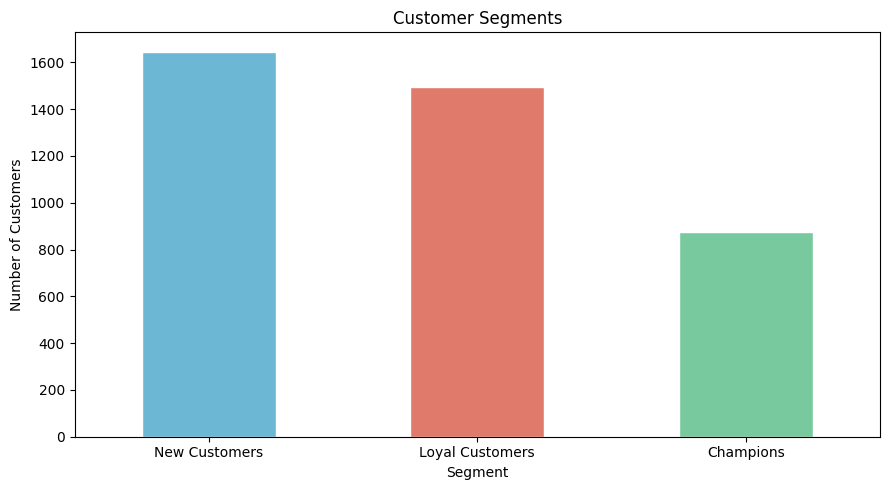

In [11]:
# Bar chart
rfm['Segment'].value_counts().plot(
    kind='bar',
    color=['#6CB8D4','#E07B6B','#79C99E','#F5C166'],
    edgecolor='white',
    figsize=(9, 5)
)
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

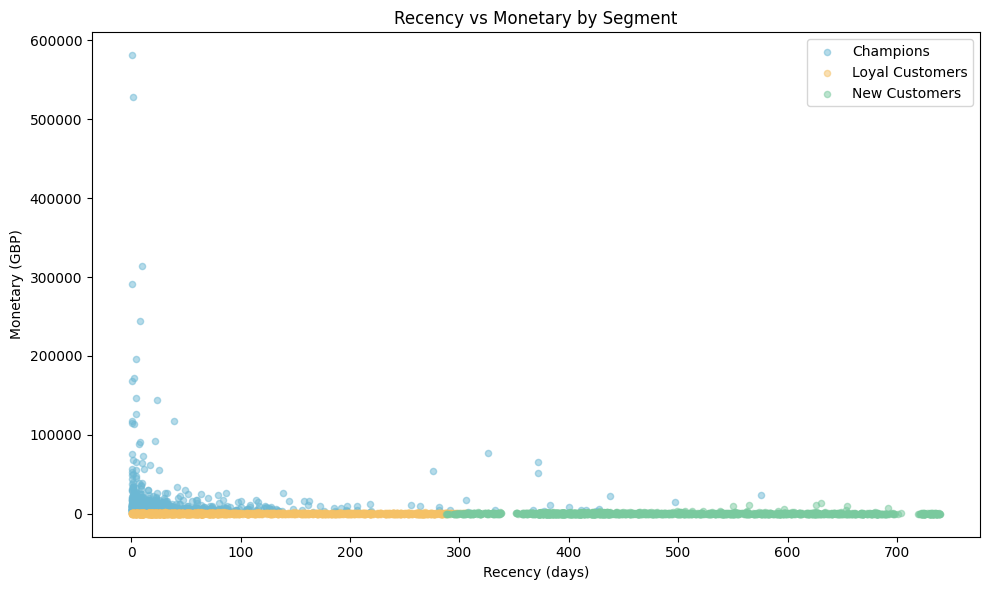

In [12]:
# Scatter plot: Recency vs Monetary
colors = {'Champions':'#6CB8D4', 'At Risk':'#E07B6B',
          'New Customers':'#79C99E', 'Loyal Customers':'#F5C166'}

plt.figure(figsize=(10, 6))
for seg, grp in rfm.groupby('Segment'):
    plt.scatter(grp['Recency'], grp['Monetary'],
                label=seg, alpha=0.5, s=20, color=colors[seg])

plt.title('Recency vs Monetary by Segment')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary (GBP)')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Features and target
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['is_churned']

# Scale
scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(X)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])

Train size: 4702
Test size : 1176


In [14]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('Model trained!')
print('\nROC-AUC Score:', round(roc_auc_score(y_test, y_proba), 4))
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Active','Churned']))

Model trained!

ROC-AUC Score: 1.0

Classification Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       589
     Churned       1.00      1.00      1.00       587

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176



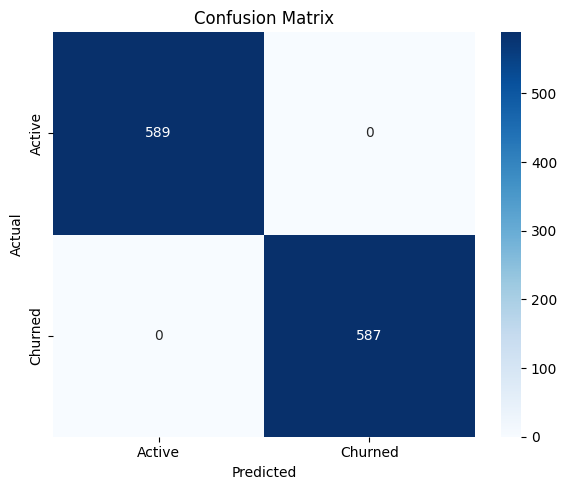

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

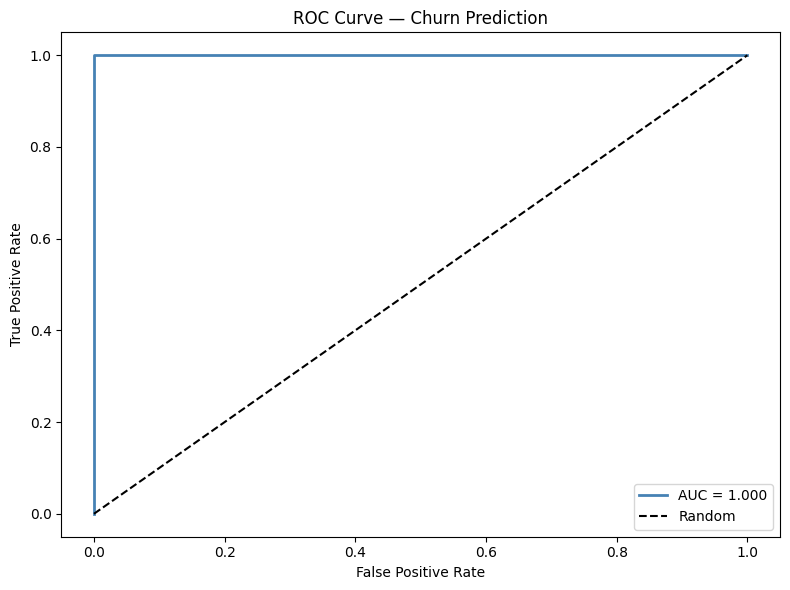

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'AUC = {auc:.3f}', linewidth=2)
plt.plot([0,1],[0,1], 'k--', label='Random')
plt.title('ROC Curve — Churn Prediction')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

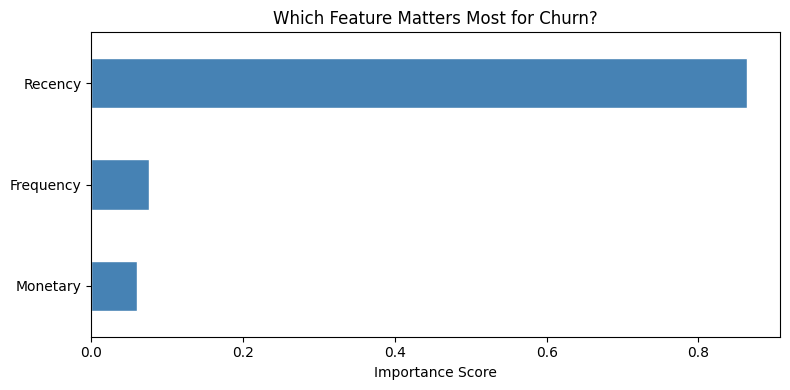

Most important feature: Recency


In [17]:
importance = pd.Series(model.feature_importances_,
                       index=['Recency','Frequency','Monetary'])

importance.sort_values().plot(kind='barh', color='steelblue',
                               edgecolor='white', figsize=(8, 4))
plt.title('Which Feature Matters Most for Churn?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Most important feature:', importance.idxmax())

In [20]:
# Save models
pickle.dump(kmeans, open('Models/kmeans_model.pkl', 'wb'))
pickle.dump(model,  open('Models/churn_model.pkl',  'wb'))
pickle.dump(scaler2,open('Models/scaler.pkl',       'wb'))

# Save RFM table
rfm.to_csv('Data/rfm_segments.csv', index=False)

print('Models saved to Models/')
print('RFM table saved to Data/rfm_segments.csv')

Models saved to Models/
RFM table saved to Data/rfm_segments.csv
